# Probabilistic Nowcasting Hujan Ekstrem Sitaro
## Retrieval-Augmented Diffusion Model dengan Spatio-Temporal Graph Conditioning

---

### Pipeline Overview

| No | Pipeline | Input | Output |
|----|----------|-------|--------|
| 1 | Data Ingestion | Koordinat + Waktu | DataFrame |
| 2 | Temporal Split | DataFrame | Train/Val/Test |
| 3 | Preprocessing | Raw Data | Normalized Tensors |
| 4 | Sliding Window | Flat Tensor | Graph Sequences |
| 5 | Retrieval Database | Features | FAISS Index |
| 6 | Spatio-Temporal GNN | Graph Seq | Embedding |
| 7 | Diffusion Training | All Conditioning | Trained Model |
| 8 | Probabilistic Inference | Current Weather | 50 Rain Samples |

## 0. Setup & Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm.notebook import tqdm

# Custom modules
from src.data.ingest import fetch_era5_data, SITARO_NODES
from src.data.temporal_loader import TemporalGraphDataset, collate_temporal_graphs
from src.models.gnn import SpatioTemporalGNN, SpatialGNN, TemporalAttention
from src.models.diffusion import ConditionalDiffusionModel, RainForecaster
from src.retrieval.base import RetrievalDatabase

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

C:\Users\Vanszs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda


---
## Pipeline 1: Data Ingestion

Mengambil data cuaca historis dari Open-Meteo Archive API (ERA5 Reanalysis).

**Variabel yang diambil:**
- Target: `precipitation` (mm/jam)
- Dynamic: temperature, humidity, pressure, wind, cloudcover
- Static: elevation, land_sea_mask
- Derived: precipitation_lag1, precipitation_lag3

In [2]:
# Load data (or fetch if not exists)
DATA_PATH = '../data/raw/sitaro_era5_2005_2025.parquet'

try:
    df = pd.read_parquet(DATA_PATH)
    print(f'✓ Data loaded from {DATA_PATH}')
except FileNotFoundError:
    print('Data not found. Fetching from Open-Meteo...')
    df = fetch_era5_data()

print(f'\nDataset Shape: {df.shape}')
print(f'Date Range: {df["date"].min()} to {df["date"].max()}')
print(f'\nColumns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

✓ Data loaded from ../data/raw/sitaro_era5_2005_2025.parquet

Dataset Shape: (552240, 8)
Date Range: 2004-12-31 16:00:00+00:00 to 2025-12-31 15:00:00+00:00

Columns:
   1. date
   2. precipitation
   3. temperature_2m
   4. relative_humidity_2m
   5. surface_pressure
   6. wind_speed_10m
   7. wind_direction_10m
   8. node_id


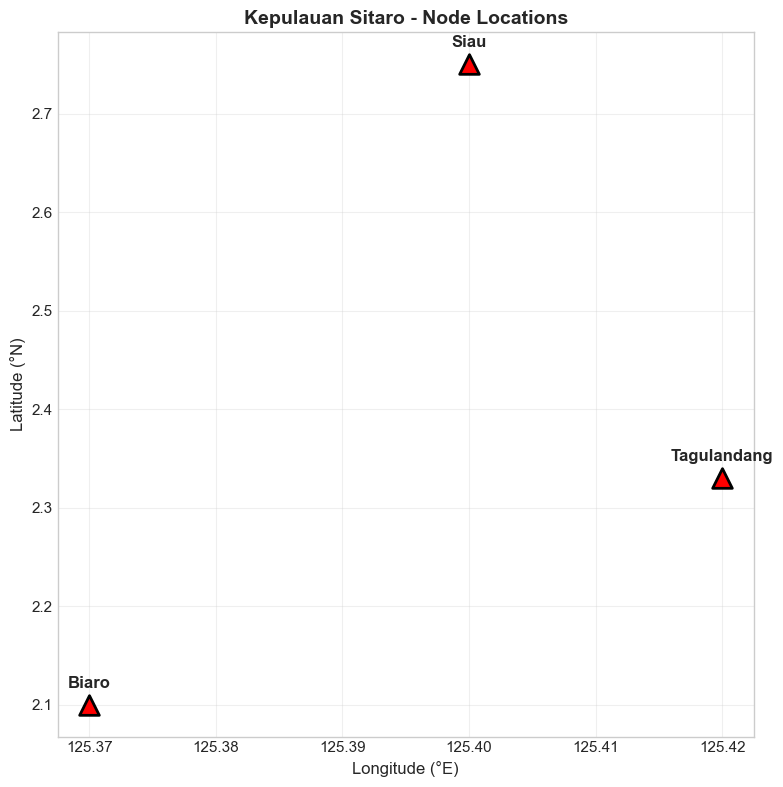

In [3]:
# Visualize: Node Locations
fig, ax = plt.subplots(figsize=(8, 8))

nodes = SITARO_NODES.copy()
ax.scatter(nodes['lon'], nodes['lat'], s=200, c='red', marker='^', edgecolors='black', linewidths=2)

for i, name in enumerate(nodes['name']):
    ax.annotate(name, (nodes['lon'].iloc[i], nodes['lat'].iloc[i]), 
                fontsize=12, ha='center', va='bottom', fontweight='bold',
                xytext=(0, 10), textcoords='offset points')

ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title('Kepulauan Sitaro - Node Locations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

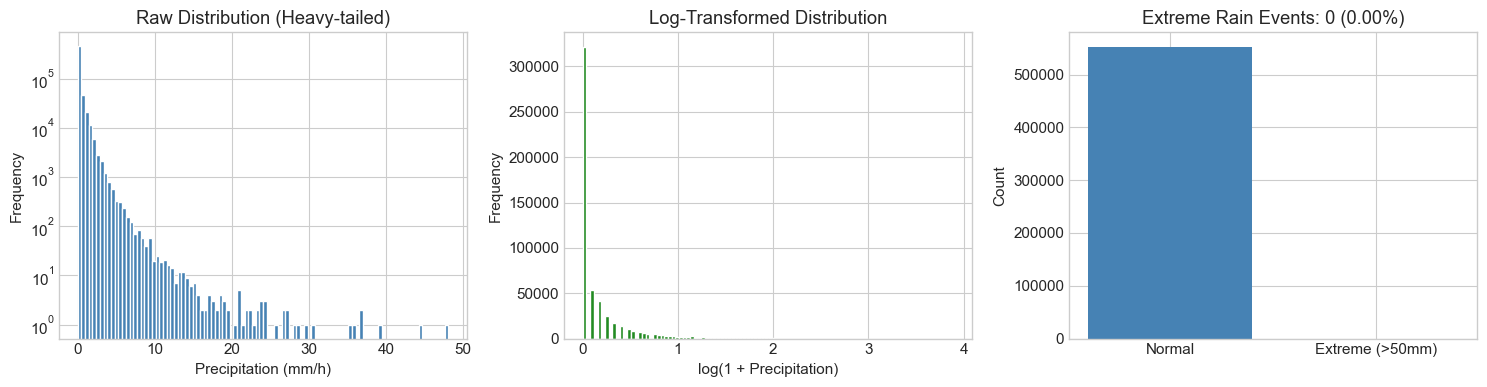


Precipitation Statistics:
count    552240.000000
mean          0.276397
std           0.710247
min           0.000000
25%           0.000000
50%           0.000000
75%           0.200000
max          48.099998
Name: precipitation, dtype: float64


In [4]:
# Visualize: Precipitation Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw distribution
axes[0].hist(df['precipitation'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Precipitation (mm/h)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Raw Distribution (Heavy-tailed)')
axes[0].set_yscale('log')

# Log-transformed
precip_log = np.log1p(df['precipitation'])
axes[1].hist(precip_log, bins=100, color='forestgreen', edgecolor='white')
axes[1].set_xlabel('log(1 + Precipitation)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Distribution')

# Extreme events
extreme_threshold = 50  # mm/h
extreme_mask = df['precipitation'] > extreme_threshold
axes[2].bar(['Normal', 'Extreme (>50mm)'], 
            [len(df) - extreme_mask.sum(), extreme_mask.sum()],
            color=['steelblue', 'crimson'])
axes[2].set_ylabel('Count')
axes[2].set_title(f'Extreme Rain Events: {extreme_mask.sum()} ({extreme_mask.mean()*100:.2f}%)')

plt.tight_layout()
plt.show()

print(f'\nPrecipitation Statistics:')
print(df['precipitation'].describe())

---
## Pipeline 2: Temporal Split (CRITICAL!)

⚠️ **MENCEGAH DATA LEAKAGE** - Random shuffle TIDAK digunakan!

| Split | Periode | Proporsi |
|-------|---------|----------|
| Training | 2005-2018 | 67% |
| Validation | 2019-2021 | 14% |
| Test | 2022-2025 | 19% |

In [5]:
def temporal_split(df, train_end='2018-12-31', val_end='2021-12-31'):
    """
    Split DataFrame berdasarkan waktu, BUKAN random.
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    
    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)
    
    train_mask = df['date'] <= train_end_dt
    val_mask = (df['date'] > train_end_dt) & (df['date'] <= val_end_dt)
    test_mask = df['date'] > val_end_dt
    
    return df[train_mask].copy(), df[val_mask].copy(), df[test_mask].copy()

# Apply temporal split
TRAIN_END = '2018-12-31'
VAL_END = '2021-12-31'

train_df, val_df, test_df = temporal_split(df, TRAIN_END, VAL_END)

print('TEMPORAL SPLIT RESULTS:')
print(f'  Training:   {len(train_df):,} rows ({len(train_df)/len(df)*100:.1f}%) | {train_df["date"].min().date()} to {train_df["date"].max().date()}')
print(f'  Validation: {len(val_df):,} rows ({len(val_df)/len(df)*100:.1f}%) | {val_df["date"].min().date()} to {val_df["date"].max().date()}')
print(f'  Test:       {len(test_df):,} rows ({len(test_df)/len(df)*100:.1f}%) | {test_df["date"].min().date()} to {test_df["date"].max().date()}')

# Verify no overlap
print(f'\n✓ Train max < Val min: {train_df["date"].max() < val_df["date"].min()}')
print(f'✓ Val max < Test min: {val_df["date"].max() < test_df["date"].min()}')

TypeError: Invalid comparison between dtype=datetime64[ns, UTC] and Timestamp

In [ ]:
# Visualize: Temporal Split Timeline
fig, ax = plt.subplots(figsize=(14, 3))

# Create timeline
years = range(2005, 2026)
colors = ['#2ecc71'] * 14 + ['#f39c12'] * 3 + ['#e74c3c'] * 4  # green, orange, red

ax.barh(0, 14, left=0, height=0.5, color='#2ecc71', label='Training (2005-2018)')
ax.barh(0, 3, left=14, height=0.5, color='#f39c12', label='Validation (2019-2021)')
ax.barh(0, 4, left=17, height=0.5, color='#e74c3c', label='Test (2022-2025)')

# Add year labels
for i, year in enumerate([2005, 2010, 2015, 2018, 2019, 2021, 2022, 2025]):
    if year <= 2018:
        x = year - 2005
    elif year <= 2021:
        x = 14 + (year - 2019)
    else:
        x = 17 + (year - 2022)
    ax.axvline(x, color='black', linestyle='--', alpha=0.3)
    ax.text(x, 0.35, str(year), ha='center', fontsize=10)

ax.set_xlim(-0.5, 21.5)
ax.set_ylim(-0.5, 0.8)
ax.set_yticks([])
ax.set_xlabel('Year Index', fontsize=12)
ax.set_title('Temporal Data Split (NO RANDOM SHUFFLE)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## Pipeline 3: Preprocessing

1. **Log Transform Target**: `y_log = log(1 + y)`
2. **Z-Score Normalization**: `x_norm = (x - μ) / σ`

⚠️ **Stats dihitung HANYA dari Training Set!**

In [ ]:
# Define feature columns
FEATURE_COLS = [
    'temperature_2m',
    'relative_humidity_2m', 
    'dewpoint_2m',
    'surface_pressure',
    'wind_speed_10m',
    'wind_direction_10m',
    'cloudcover',
    'precipitation_lag1',
    'precipitation_lag3',
    'elevation',
]

# Use only available columns
feature_cols = [c for c in FEATURE_COLS if c in train_df.columns]
print(f'Using {len(feature_cols)} features:')
for col in feature_cols:
    print(f'  - {col}')

In [ ]:
def compute_stats_from_train(train_df, feature_cols):
    """
    Compute normalization stats ONLY from training data.
    """
    # Target stats (with log transform)
    target_log = np.log1p(train_df['precipitation'].values)
    t_mean = torch.tensor(target_log.mean(), dtype=torch.float32)
    t_std = torch.tensor(target_log.std(), dtype=torch.float32)
    
    # Feature stats
    features = train_df[feature_cols].values
    c_mean = torch.tensor(features.mean(axis=0), dtype=torch.float32)
    c_std = torch.tensor(features.std(axis=0), dtype=torch.float32)
    
    return {'t_mean': t_mean, 't_std': t_std, 'c_mean': c_mean, 'c_std': c_std}

# Compute stats from TRAINING ONLY
stats = compute_stats_from_train(train_df, feature_cols)

print('Normalization Stats (from Training Data ONLY):')
print(f'  Target Log Mean: {stats["t_mean"]:.4f}')
print(f'  Target Log Std:  {stats["t_std"]:.4f}')
print(f'\nFeature Means:')
for i, col in enumerate(feature_cols):
    print(f'  {col}: μ={stats["c_mean"][i]:.2f}, σ={stats["c_std"][i]:.2f}')

In [ ]:
# Visualize: Before vs After Normalization
fig, axes = plt.subplots(2, 5, figsize=(16, 6))

sample_features = feature_cols[:5]  # First 5 features

for i, col in enumerate(sample_features):
    # Before
    axes[0, i].hist(train_df[col].dropna(), bins=50, color='steelblue', alpha=0.7)
    axes[0, i].set_title(f'{col}\n(Before)', fontsize=9)
    axes[0, i].tick_params(labelsize=8)
    
    # After
    normalized = (train_df[col].values - stats['c_mean'][i].numpy()) / (stats['c_std'][i].numpy() + 1e-5)
    axes[1, i].hist(normalized, bins=50, color='forestgreen', alpha=0.7)
    axes[1, i].set_title(f'{col}\n(After: μ≈0, σ≈1)', fontsize=9)
    axes[1, i].tick_params(labelsize=8)

plt.suptitle('Normalization: Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Pipeline 4: Sliding Window & Graph Construction

- **Sequence Length**: 6 timesteps
- **Nodes**: 3 (Siau, Tagulandang, Biaro)
- **Edges**: Fully connected (6 edges)

```
Input:  [Graph_t-5, Graph_t-4, Graph_t-3, Graph_t-2, Graph_t-1, Graph_t]
Target: precipitation(t+1)
```

In [ ]:
# Create datasets
SEQ_LEN = 6
BATCH_SIZE = 32

train_dataset = TemporalGraphDataset(
    df=train_df,
    feature_cols=feature_cols,
    seq_len=SEQ_LEN,
    stats=stats
)

val_dataset = TemporalGraphDataset(
    df=val_df,
    feature_cols=feature_cols,
    seq_len=SEQ_LEN,
    stats=stats  # SAME stats from training!
)

print(f'Training Dataset: {len(train_dataset)} samples')
print(f'Validation Dataset: {len(val_dataset)} samples')

In [ ]:
# Inspect one sample
graphs, target, context = train_dataset[0]

print('Sample Structure:')
print(f'  Graphs: {len(graphs)} timesteps')
print(f'  Graph[0].x shape: {graphs[0].x.shape} (nodes × features)')
print(f'  Graph[0].edge_index shape: {graphs[0].edge_index.shape}')
print(f'  Target shape: {target.shape}')
print(f'  Context shape: {context.shape}')

# Visualize edge connections
print(f'\nEdge Index (COO format):')
print(f'  Source nodes: {graphs[0].edge_index[0].tolist()}')
print(f'  Target nodes: {graphs[0].edge_index[1].tolist()}')

In [ ]:
# Visualize: Graph Structure
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Create graph
G = nx.DiGraph()
node_names = ['Siau', 'Tagulandang', 'Biaro']
G.add_nodes_from(node_names)

edge_index = graphs[0].edge_index.numpy()
for src, tgt in zip(edge_index[0], edge_index[1]):
    G.add_edge(node_names[src], node_names[tgt])

# Draw graph
pos = {'Siau': (0, 1), 'Tagulandang': (0.5, 0.5), 'Biaro': (0, 0)}
nx.draw(G, pos, ax=axes[0], with_labels=True, node_color='lightblue', 
        node_size=2000, font_size=10, font_weight='bold',
        arrows=True, arrowsize=20, edge_color='gray')
axes[0].set_title('Graph Structure (Fully Connected)', fontsize=12, fontweight='bold')

# Show sliding window
timesteps = ['t-5', 't-4', 't-3', 't-2', 't-1', 't']
axes[1].bar(timesteps, [1]*6, color='steelblue', alpha=0.7)
axes[1].axvline(5.5, color='red', linestyle='--', linewidth=2)
axes[1].text(5.7, 0.5, 'Predict\nt+1', fontsize=10, color='red', fontweight='bold')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Graph Input')
axes[1].set_title('Sliding Window (seq_len=6)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Pipeline 5: Retrieval Database (FAISS)

⚠️ **Index HANYA dari Training Data!**

- Algorithm: Flat L2 (brute-force)
- K neighbors: 3
- Distance: Euclidean

In [ ]:
# Build retrieval database from TRAINING ONLY
train_features = train_df[feature_cols].values
train_features_norm = (train_features - stats['c_mean'].numpy()) / (stats['c_std'].numpy() + 1e-5)

retrieval_db = RetrievalDatabase(embedding_dim=len(feature_cols))
retrieval_db.add_items(train_features_norm, train_features_norm)

print(f'FAISS Index built with {len(train_features_norm):,} training samples')
print(f'Embedding dimension: {len(feature_cols)}')

In [ ]:
# Test retrieval
K_NEIGHBORS = 3

# Query with a sample
query = train_features_norm[1000:1001]  # Single query
retrieved = retrieval_db.query(query, k=K_NEIGHBORS)

print(f'Query shape: {query.shape}')
print(f'Retrieved shape: {retrieved.shape} (batch × k × features)')
print(f'\nK={K_NEIGHBORS} Nearest Neighbors found!')

---
## Pipeline 6: Spatio-Temporal GNN

**Architecture:**
1. **Spatial**: 2-layer GAT (Graph Attention Network)
2. **Temporal**: Multi-head Self-Attention
3. **Output**: Graph embedding [B, 64]

In [ ]:
# Initialize models
HIDDEN_DIM = 128
GRAPH_DIM = 64
CONTEXT_DIM = len(feature_cols)
RETRIEVAL_DIM = CONTEXT_DIM * K_NEIGHBORS

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# SpatioTemporal GNN
st_gnn = SpatioTemporalGNN(
    node_features=CONTEXT_DIM,
    hidden_dim=HIDDEN_DIM // 2,
    output_dim=GRAPH_DIM,
    num_gat_heads=4,
    num_attn_heads=4,
    seq_len=SEQ_LEN
).to(device)

print(f'SpatioTemporalGNN Parameters: {sum(p.numel() for p in st_gnn.parameters()):,}')
print(f'\nArchitecture:')
print(st_gnn)

In [ ]:
# Test forward pass
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset, 
    batch_size=4, 
    shuffle=True,
    collate_fn=collate_temporal_graphs
)

batched_graphs, targets, contexts = next(iter(train_loader))
batched_graphs = [g.to(device) for g in batched_graphs]

with torch.no_grad():
    graph_emb = st_gnn(batched_graphs)

print(f'Input: {len(batched_graphs)} graph batches')
print(f'Output Graph Embedding: {graph_emb.shape}')
print(f'\n✓ SpatioTemporalGNN forward pass successful!')

---
## Pipeline 7: Conditional Diffusion Model Training

**Conditioning:**
1. Time embedding (sinusoidal)
2. Context embedding (current weather)
3. Retrieval embedding (historical analogs)
4. Graph embedding (spatio-temporal) ← **Thesis novelty!**

In [ ]:
# Initialize Diffusion Model
diff_model = ConditionalDiffusionModel(
    input_dim=1,
    context_dim=CONTEXT_DIM,
    retrieval_dim=RETRIEVAL_DIM,
    graph_dim=GRAPH_DIM,
    hidden_dim=HIDDEN_DIM
)

forecaster = RainForecaster(diff_model, device=device)

print(f'DiffusionModel Parameters: {sum(p.numel() for p in diff_model.parameters()):,}')
print(f'\nTotal Trainable Parameters: {sum(p.numel() for p in st_gnn.parameters()) + sum(p.numel() for p in diff_model.parameters()):,}')

In [ ]:
# Training loop (mini version for demo)
EPOCHS = 3  # Reduced for notebook demo

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    collate_fn=collate_temporal_graphs
)

# Combined optimizer
all_params = list(st_gnn.parameters()) + list(diff_model.parameters())
optimizer = torch.optim.AdamW(all_params, lr=1e-3, weight_decay=1e-4)

print(f'Starting training for {EPOCHS} epochs...')
print(f'Batches per epoch: {len(train_loader)}')

losses = []

for epoch in range(EPOCHS):
    st_gnn.train()
    forecaster.model.train()
    epoch_loss = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for batched_graphs, targets, contexts in pbar:
        batched_graphs = [g.to(device) for g in batched_graphs]
        targets = targets.to(device)
        contexts = contexts.to(device)
        
        # Get graph embedding
        graph_emb = st_gnn(batched_graphs)
        
        # Get retrieval
        with torch.no_grad():
            retrieved = retrieval_db.query(contexts.cpu().numpy(), k=K_NEIGHBORS)
            retrieved = retrieved.to(device)
        
        # Diffusion step
        optimizer.zero_grad()
        noise = torch.randn_like(targets).to(device)
        timesteps = torch.randint(0, 1000, (targets.shape[0],), device=device).long()
        noisy_target = forecaster.scheduler.add_noise(targets, noise, timesteps)
        
        noise_pred = forecaster.model(
            noisy_target, timesteps, contexts, retrieved, graph_emb
        )
        
        loss = forecaster.criterion(noise_pred, noise)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1} Average Loss: {avg_loss:.4f}')

In [ ]:
# Visualize: Training Loss
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(losses)+1), losses, marker='o', linewidth=2, markersize=8)
plt.xlabel('Epoch')
plt.ylabel('Average Loss (MSE)')
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Pipeline 8: Probabilistic Inference

Generate 50 probabilistic rain samples for uncertainty quantification.

In [ ]:
# Inference function
@torch.no_grad()
def run_inference(graphs_sequence, context, st_gnn, forecaster, retrieval_db, stats, num_samples=50):
    st_gnn.eval()
    forecaster.model.eval()
    
    # Graph embedding
    graph_emb = st_gnn(graphs_sequence)
    
    # Retrieval
    retrieved = retrieval_db.query(context.cpu().numpy(), k=K_NEIGHBORS)
    retrieved = retrieved.to(device)
    
    # Sample
    samples = forecaster.sample(
        condition=context,
        retrieved=retrieved,
        graph_emb=graph_emb,
        num_samples=num_samples
    )
    
    # Denormalize
    samples_log = samples * stats['t_std'] + stats['t_mean']
    samples_mm = torch.expm1(samples_log)
    samples_mm = torch.clamp(samples_mm, min=0)
    
    return samples_mm.cpu().numpy().flatten()

# Get a sample for inference
graphs, target, context = train_dataset[100]
batched_graphs = [g.unsqueeze(0).to(device) if hasattr(g, 'unsqueeze') else g.to(device) for g in graphs]

# Need to batch graphs properly
from torch_geometric.data import Batch
batched_graphs = [Batch.from_data_list([g]).to(device) for g in graphs]
context = context.unsqueeze(0).to(device)

# Run inference
predictions = run_inference(
    batched_graphs, context, st_gnn, forecaster, retrieval_db, stats, num_samples=50
)

print(f'Generated {len(predictions)} probabilistic samples')
print(f'\nPrediction Statistics:')
print(f'  Mean: {predictions.mean():.2f} mm')
print(f'  Std:  {predictions.std():.2f} mm')
print(f'  Min:  {predictions.min():.2f} mm')
print(f'  Max:  {predictions.max():.2f} mm')

In [ ]:
# Visualize: Probabilistic Predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of samples
axes[0].hist(predictions, bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(predictions.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {predictions.mean():.2f}')
axes[0].set_xlabel('Predicted Precipitation (mm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('50 Probabilistic Samples', fontsize=12, fontweight='bold')
axes[0].legend()

# Box plot
bp = axes[1].boxplot(predictions, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[1].set_ylabel('Predicted Precipitation (mm)')
axes[1].set_title('Distribution (Box Plot)', fontsize=12, fontweight='bold')

# Percentiles
percentiles = [10, 25, 50, 75, 90]
perc_values = [np.percentile(predictions, p) for p in percentiles]
axes[2].bar([f'P{p}' for p in percentiles], perc_values, color='forestgreen', edgecolor='white')
axes[2].set_ylabel('Precipitation (mm)')
axes[2].set_title('Percentiles (Uncertainty)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Extreme event probability
thresholds = [50, 100, 150]
print('\nExtreme Event Probabilities:')
for t in thresholds:
    prob = (predictions > t).mean() * 100
    print(f'  P(Rain > {t}mm): {prob:.1f}%')

---
## Summary

### Pipeline Completed:

1. ✅ **Data Ingestion**: 20 tahun data ERA5
2. ✅ **Temporal Split**: Train 2005-2018 / Val 2019-2021 / Test 2022-2025
3. ✅ **Preprocessing**: Log transform + Z-score normalization
4. ✅ **Sliding Window**: 6-timestep graph sequences
5. ✅ **Retrieval Database**: FAISS dengan k=3 neighbors
6. ✅ **Spatio-Temporal GNN**: GAT + TemporalAttention
7. ✅ **Diffusion Training**: DDPM with all conditioning
8. ✅ **Probabilistic Inference**: 50 ensemble samples

### Key Features:

- 🔒 **No Data Leakage**: Strict temporal split
- 📊 **Probabilistic**: Uncertainty quantification
- 🌐 **Graph-based**: Spatio-temporal dependencies
- 🔍 **Retrieval-Augmented**: Historical analog search